
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_07_abc_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: ABC del aprendizaje de máquina

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

## 1. Entendimiento de los datos

El primer paso consiste en comprender el origen y la naturaleza de los datos. Es fundamental identificar la fuente (por ejemplo, si provienen de un censo, sensores o registros operacionales), así como la unidad de observación, es decir, qué representa cada fila: una persona, un distrito, una vivienda, entre otros.

También es importante reconocer el tipo de variables presentes en el conjunto de datos, distinguiendo entre variables numéricas, categóricas, espaciales o temporales. En esencia, la pregunta clave en esta etapa es: ¿qué representa físicamente cada observación?


## 2. Calidad de datos (Data Quality)

Una vez entendido el dataset, se debe evaluar su calidad. Esto implica analizar la presencia de valores faltantes y determinar si su ausencia es aleatoria o responde a algún patrón estructural. Asimismo, es necesario examinar los valores atípicos (outliers), diferenciando entre posibles errores de medición y fenómenos reales del sistema.

Adicionalmente, se debe verificar la consistencia de los datos, asegurando que las unidades sean correctas y que los valores se encuentren dentro de rangos razonables.


## 3. Análisis exploratorio (EDA)

El análisis exploratorio permite obtener una primera comprensión de la estructura del dataset. En esta fase se estudian las distribuciones de las variables mediante histogramas o funciones de densidad, lo que permite identificar asimetrías, concentraciones o comportamientos anómalos.

También se analizan las relaciones entre variables, por ejemplo, mediante correlaciones o gráficos de dispersión. Finalmente, es útil examinar la geometría del conjunto de datos, identificando posibles agrupaciones (clusters) o patrones espaciales como gradientes.

## 5. Feature Engineering

En esta etapa se transforman las variables originales para construir representaciones más informativas del problema. Esto puede implicar la creación de nuevas variables derivadas o la aplicación de transformaciones que faciliten el modelado.

Por ejemplo, es común definir medidas de densidad como:

$
\text{rooms_per_household} = \frac{\text{total_rooms}}{\text{households}}
$

o variables como el número de personas por hogar. También pueden aplicarse transformaciones como el logaritmo de la variable objetivo:

$$
\log(y)
$$


## 6. Partición del dataset

Para evaluar correctamente el desempeño de los modelos, es necesario dividir el conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Esta separación permite evitar el sobreajuste y obtener estimaciones realistas del rendimiento.

Es importante enfatizar que el conjunto de prueba debe permanecer completamente aislado durante el desarrollo del modelo.


## 7. Modelado

En función del problema planteado, se selecciona un modelo adecuado, como regresión lineal, árboles de decisión, métodos de ensamble o redes neuronales. En términos generales, el objetivo es aproximar una relación funcional entre las variables de entrada y la variable objetivo:

$$
y = f_\theta(X)
$$


## 8. Entrenamiento

El entrenamiento consiste en ajustar los parámetros del modelo mediante la minimización de una función de costo. Un ejemplo común en problemas de regresión es el error cuadrático medio:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Este proceso se realiza mediante algoritmos de optimización, como el gradiente descendente.


## 9. Evaluación

Una vez entrenado el modelo, se evalúa su desempeño utilizando métricas adecuadas como el error absoluto medio (MAE), el error cuadrático medio (RMSE) o el coeficiente de determinación (R²):

$$
\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

Es fundamental que esta evaluación se realice sobre datos no utilizados durante el entrenamiento.


## 10. Interpretabilidad

Además del rendimiento, es importante comprender cómo el modelo utiliza las variables. Esto incluye analizar la importancia de las variables y la sensibilidad de las predicciones frente a cambios en las entradas.


## 11. Incertidumbre

Todo modelo presenta cierto grado de incertidumbre, por lo que es necesario cuantificarla. Esto puede hacerse mediante intervalos de confianza, técnicas de remuestreo como bootstrap o analizando la variabilidad de las predicciones.


## 12. Validación del modelo

La validación busca asegurar que el modelo generaliza adecuadamente a nuevos datos. Esto implica evaluar su robustez frente a diferentes particiones o condiciones.



## 14. Comunicación

Los resultados deben presentarse de forma clara y coherente, apoyándose en visualizaciones adecuadas y evitando interpretaciones exageradas. La comunicación es clave para que el análisis tenga impacto.

## 15. Deployment

En contextos aplicados, el modelo puede ser desplegado en producción, por ejemplo, mediante una API o procesos batch. Esto permite su uso en sistemas reales.

## 16. Monitoreo y drift

Una vez en producción, es necesario monitorear el comportamiento del modelo, especialmente posibles cambios en la distribución de los datos:

$$
P_{\text{train}}(X) \neq P_{\text{prod}}(X)
$$

Estos cambios pueden afectar el desempeño del modelo con el tiempo.

## 17. Reproducibilidad

Finalmente, todo el proceso debe ser reproducible. Esto implica mantener un adecuado versionado de los datos, código limpio, control de semillas aleatorias y registro de experimentos.

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

# 1.0 Análisis del data frame

1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

  ```python
  df.info()
  df.describe()
  df.isnull().sum()
  df.isna().sum()
```
Estos dos últimos son equivalentes.

3. ¿Cuántas variables tiene el dataset y de qué tipo son?
4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

5. Determinar los elementos únicos dentro de la columna ocean_proximity.

6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv")
df.info()
df.describe()
df.isnull().sum()
df.isna().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
cols = ["housing_median_age",   "total_rooms",  "total_bedrooms",   "population",   "households",   "median_income",    "median_house_value"]
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### [Diagrama de caja](https://en.wikipedia.org/wiki/Box_plot)


### Diagrama de caja

![box](https://upload.wikimedia.org/wikipedia/commons/e/ed/Box_Plot_Picture.png)



### Interpretación de un diagrama de caja

- Desde el minimo al valor más bajo de la caja: primer cuartil, 25% de los datos
- Desde el valor más bajo de la caja hasta la mediana: segundo cuartil, 25% de los datos
- Desde la mediana hasta el valor mas alto de la caja : tercer cuartil, 25% de los datos
- Desde el valor mas alto de la caja hasta el máximo: Cuarto  cuartil, 25% de los datos


El rango intercuartil $IQR = Q_3-Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:

$Max = Q3 + 1.5IQR$

$Min = Q1 - 1.5IQR$



El cuartil puede ser determinado como sigue:

Para calcular los cuartiles de una lista de números:

- Ordenar los números de menor a mayor.
- Calcular la posición de cada cuartil usando la fórmula: Q = a (N+1) / 4, donde Q es la posición del cuartil, a es el número del cuartil (1, 2 o 3), y N es el número total de datos.
- Si la posición del cuartil es un número entero, el valor del cuartil es el dato que está en esa posición.
- Si la posición del cuartil es un número decimal, el valor del cuartil se interpola usando la fórmula: Q = x + d (y - x), donde Q es el valor del cuartil, x es el dato anterior a la posición del cuartil, y es el dato posterior a la posición del cuartil, y d es la parte decimal de la posición del cuartil.


Veamos un ejemplo:



In [ ]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(len(T))
print(f"T sort:{Tsort}")
len(T)/4

In [ ]:

IQR=9
max_ = 75 + 1.5*IQR
min_ = 66 - 1.5*IQR
print(max_)
print(min_)
plt.boxplot(T)

8. Empleando el siguiente código realiza el gráfico boxplot,
```python
#draw boxplot
df.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()
```

9. Determina la matrix de correlación.

### [Matrix de correlación](https://en.wikipedia.org/wiki/Correlation)

¿Como se determina la matrix de correlación?

![Matrix de correlación](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1920px-Correlation_examples2.svg.png)



```python
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

# 2.0 Preparacion del data frame

## Evitar el data *Snooping bias*.

En algunos casos se sugiere dividir los datos en entrenamiento y test desde el principio dado que el cerebro puede sobreajustar el dataset y los resultados no significativos se pueden volver significativos. El procedimiento correcto es probar cualquier hipótesis en un conjunto de datos que no se utilizó para generar las hipótesis inicial.


## *Sampling bias*

Si el dataset es lo suficientemente grande un muestreo aleatorio de la muestra puede ser considerado, sin embargo si la muestra es pequena se debe garantizar homegeniedad en el dataset de entrenamiento.


Ejemplo:

Por ejemplo, la población de EE. UU. esta compuesto por un 51,3 % de mujeres y un 48,7 % de hombres, por lo que una encuesta bien realizada en EEUU
trata de mantener esta proporción en la muestra: 513 mujeres y 487 hombres. Esto se llama muestreo estratificado(stratified sampling): la población se divide en subgrupos homogéneos llamados estratos(strata), y se muestrea el número correcto de instancias de cada estrato para garantizar que el
El conjunto de prueba es representativo de la población general. Si usaran muestras puramente aleatorias, habría alrededor del 12% de posibilidades de muestrear un conjunto de prueba sesgado con menos del 49% de mujeres o más del 54% de mujeres. De cualquier manera, los resultados de la encuesta serían
significativamente sesgada.


12. ¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```


13. División del dataset en grupos:


La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df["income_cat"] = pd.cut(df["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df["income_cat"].value_counts() / len(df)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
```

13. Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```




# Limpieza de datos

Lo que sigue son códigos que pueden servir para limpiar los datos.

```python

df.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()

```

##imputer

Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):


```python
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop("ocean_proximity", axis=1)

imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

imp_mean.statistics_
```

14. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```


# Manejo de texto y atributos categóricos
15.  ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```


# Escalamiento de variables

16. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```


17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

1. ¿que puede concluir respecto al modelo empleado?
2. ¿El modelo de regresión lineal es valido para lo construido,
3. ¿qué informacion nos da el score?
4. ¿Puede ser ajustado a otro modelo?
5. ¿Como puede autmatizar todo el proceso empleando pipelines?






PUNTO 2: ESTADO DE LOS DATOS

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

--- df.describe() ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861     

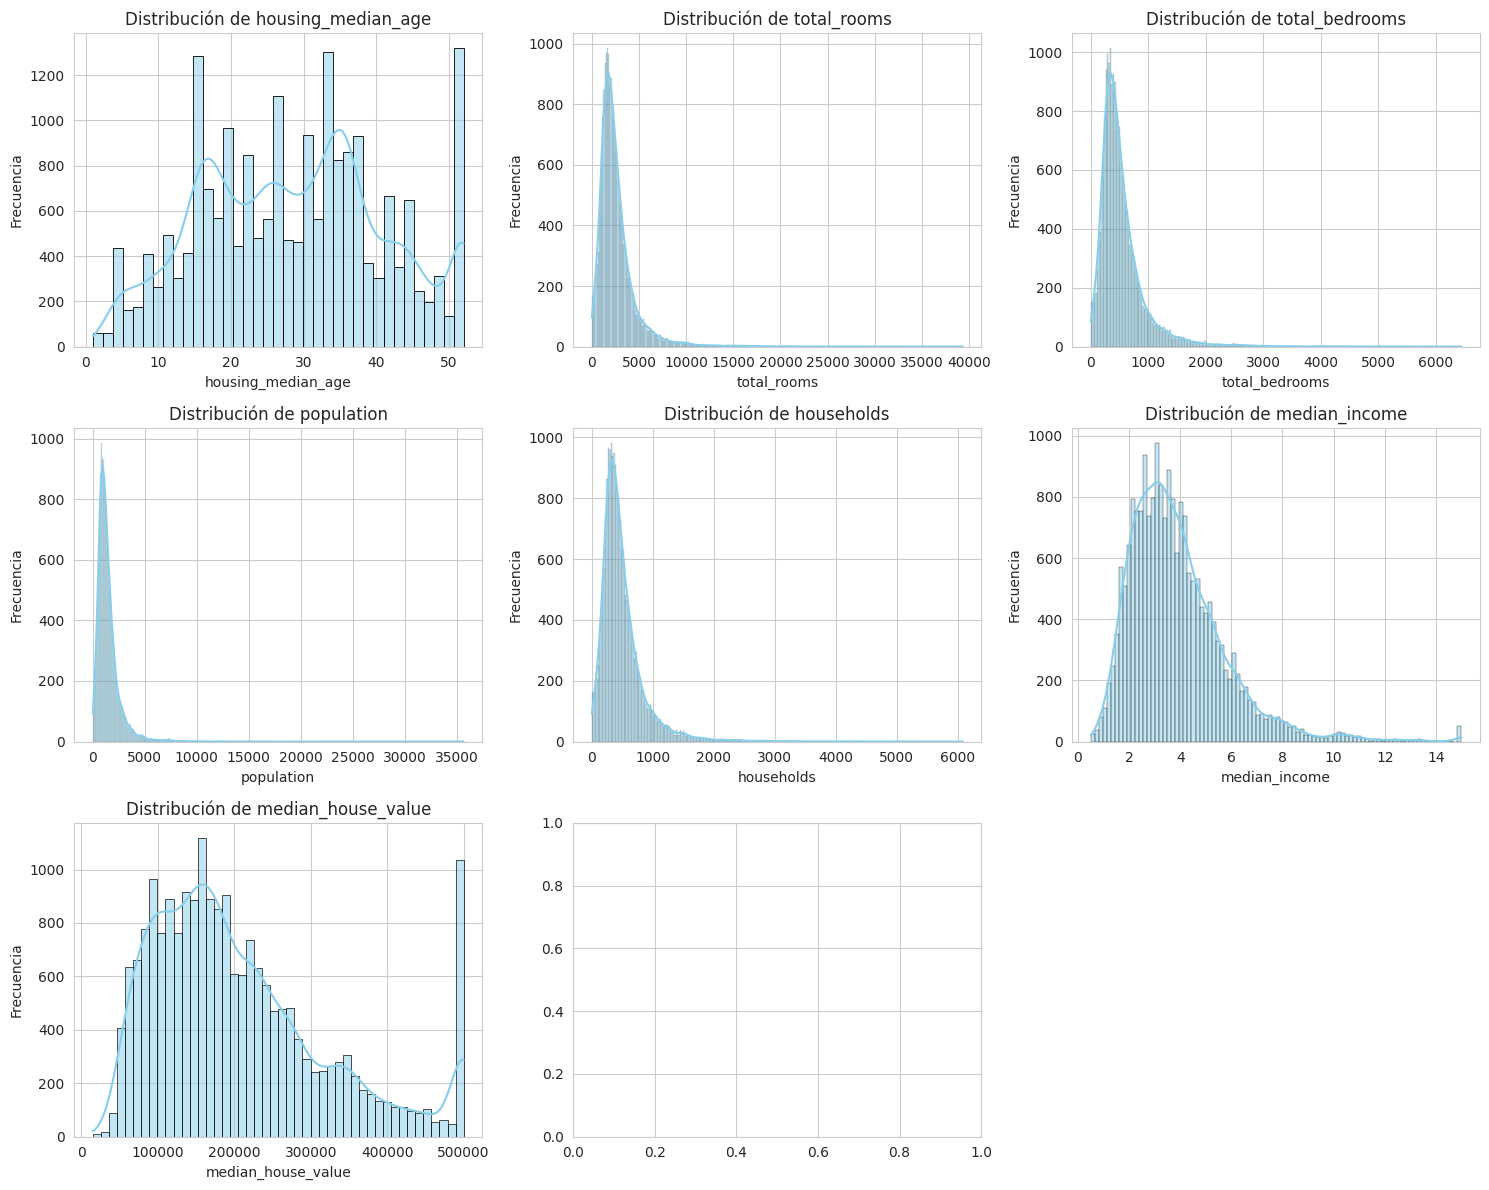


Histogramas adicionales: 'median_house_value' segmentado por 'ocean_proximity'


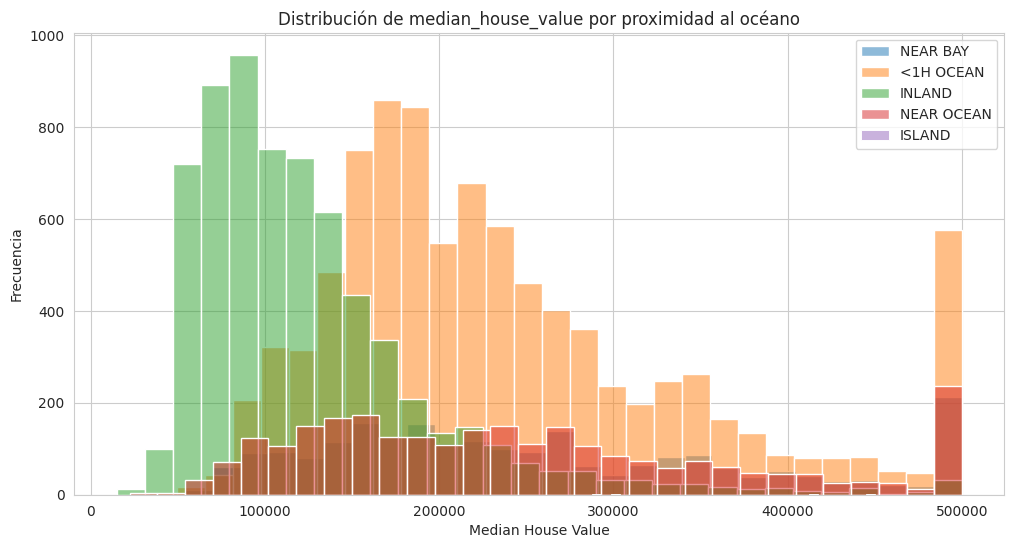

In [ ]:
# 1.0 Análisis del data frame

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)
numeric_cols = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value",
]

print("=" * 60)
print("PUNTO 2: ESTADO DE LOS DATOS")
print("=" * 60)
df.info()

print("\nResumen estadístico numérico:")
print(df[numeric_cols].describe().round(2))

print("\nResumen de valores faltantes:")
missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing = missing[missing["missing_count"] > 0]
print(missing if not missing.empty else "No existen valores faltantes.")

print("\nPUNTO 3: VARIABLES Y TIPOS")
print(f"Número total de variables (columnas): {df.shape[1]}")
print(df.dtypes)

print("\nPUNTO 4: ELEMENTOS ÚNICOS EN 'ocean_proximity'")
ocean_counts = df["ocean_proximity"].value_counts()
print(ocean_counts)
print(pd.DataFrame({"count": ocean_counts, "pct": (ocean_counts / len(df) * 100).round(2)}))

print("\nPUNTO 5: ESTADÍSTICAS POR CATEGORÍA")
grouped_stats = df.groupby("ocean_proximity")[numeric_cols].agg(["mean", "median", "std"]).round(2)
print(grouped_stats)

print("\nPUNTO 6: CORRELACIÓN NUMÉRICA")
corr = df[numeric_cols].corr().round(2)
print(corr)

print("\nPUNTO 7: HISTOGRAMAS")
sns.set_style("whitegrid")
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.ravel(axes)

for index, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[index], color="skyblue", edgecolor="black")
    axes[index].set_title(f"Distribución de {col}", fontsize=12)
    axes[index].set_xlabel(col)
    axes[index].set_ylabel("Frecuencia")

for index in range(len(numeric_cols), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for category in df["ocean_proximity"].dropna().unique():
    subset = df[df["ocean_proximity"] == category]
    sns.histplot(subset["median_house_value"], label=category, alpha=0.35, bins=30, stat="density", element="step", fill=False)
plt.legend()
plt.title("Distribución de median_house_value por proximidad al océano")
plt.xlabel("median_house_value")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()

## Respuestas útiles 1 a 20

1. El dataset representa bloques de vivienda del censo de California de 1990; cada fila es una observación geográfica con información demográfica y de vivienda.
2. La calidad de datos es buena en general; el principal faltante aparece en `total_bedrooms` y debe tratarse antes de modelar.
3. Hay variables numéricas y una categórica principal (`ocean_proximity`); la variable objetivo es `median_house_value`.
4. Los valores faltantes no son muchos, pero conviene tratarlos con imputación antes de entrenar modelos.
5. `ocean_proximity` contiene categorías geográficas que deben revisarse por frecuencia y efecto sobre el precio.
6. El promedio por categoría muestra diferencias claras entre zonas costeras e interiores; esa señal geográfica es relevante.
7. Los histogramas muestran asimetría y colas largas en varias variables; no conviene asumir normalidad.
8. El boxplot por `ocean_proximity` permite ver que el valor de vivienda cambia mucho según la ubicación.
9. La matriz de correlación sirve para detectar relaciones fuertes, especialmente entre variables de tamaño y el objetivo.
10. El pairplot ayuda a visualizar relaciones bivariadas y posibles separaciones entre grupos.
11. El scatter plot coloreado por `median_house_value` deja ver gradientes espaciales y patrones de valor.
12. `train_test_split` aleatorio puede sesgar la muestra; para este problema es mejor una división estratificada por ingreso.
13. Crear `income_cat` permite estratificar mejor el conjunto y mantener proporciones similares en train y test.
14. Comparar proporciones entre población total, train estratificado y train aleatorio ayuda a medir el sesgo de muestreo.
15. `OneHotEncoder` transforma `ocean_proximity` en variables binarias para usarla en modelos numéricos.
16. `MinMaxScaler` lleva las variables a una escala comparable y evita que una magnitud domine el modelo.
17. La solución completa debe usar limpieza, imputación, codificación y escalamiento dentro de un flujo reproducible.
18. Agregar variables como `rooms_per_household`, `bedrooms_per_room` y `population_per_household` mejora la capacidad explicativa.
19. La imputación con la mediana es una opción robusta para `total_bedrooms` y mantiene más filas útiles.
20. La recomendación final es usar pipeline + estratificación + variables derivadas, y no eliminar outliers sin contexto.

DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS

Variable: housing_median_age
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 18.00
Q2 (mediana, 50%): 29.00
Q3 (tercer cuartil, 75%): 37.00
IQR (rango intercuartil): 19.00

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -10.50
Límite superior (Q3 + 1.5*IQR): 65.50

--- Outliers detectados ---
Total de outliers: 0 (0.00%)
  - Outliers inferiores (< -10.50): 0
  - Outliers superiores (> 65.50): 0

Variable: total_rooms
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 1447.25
Q2 (mediana, 50%): 2127.00
Q3 (tercer cuartil, 75%): 3148.00
IQR (rango intercuartil): 1700.75

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -1103.88
Límite superior (Q3 + 1.5*IQR): 5699.12

--- Outliers detectados ---
Total de outliers: 1286 (6.23%)
  - Outliers inferiores (< -1103.88): 0
  - Outliers superiores (> 5699.12): 1286

Ejemplos de outliers superiores (los 5 más altos):

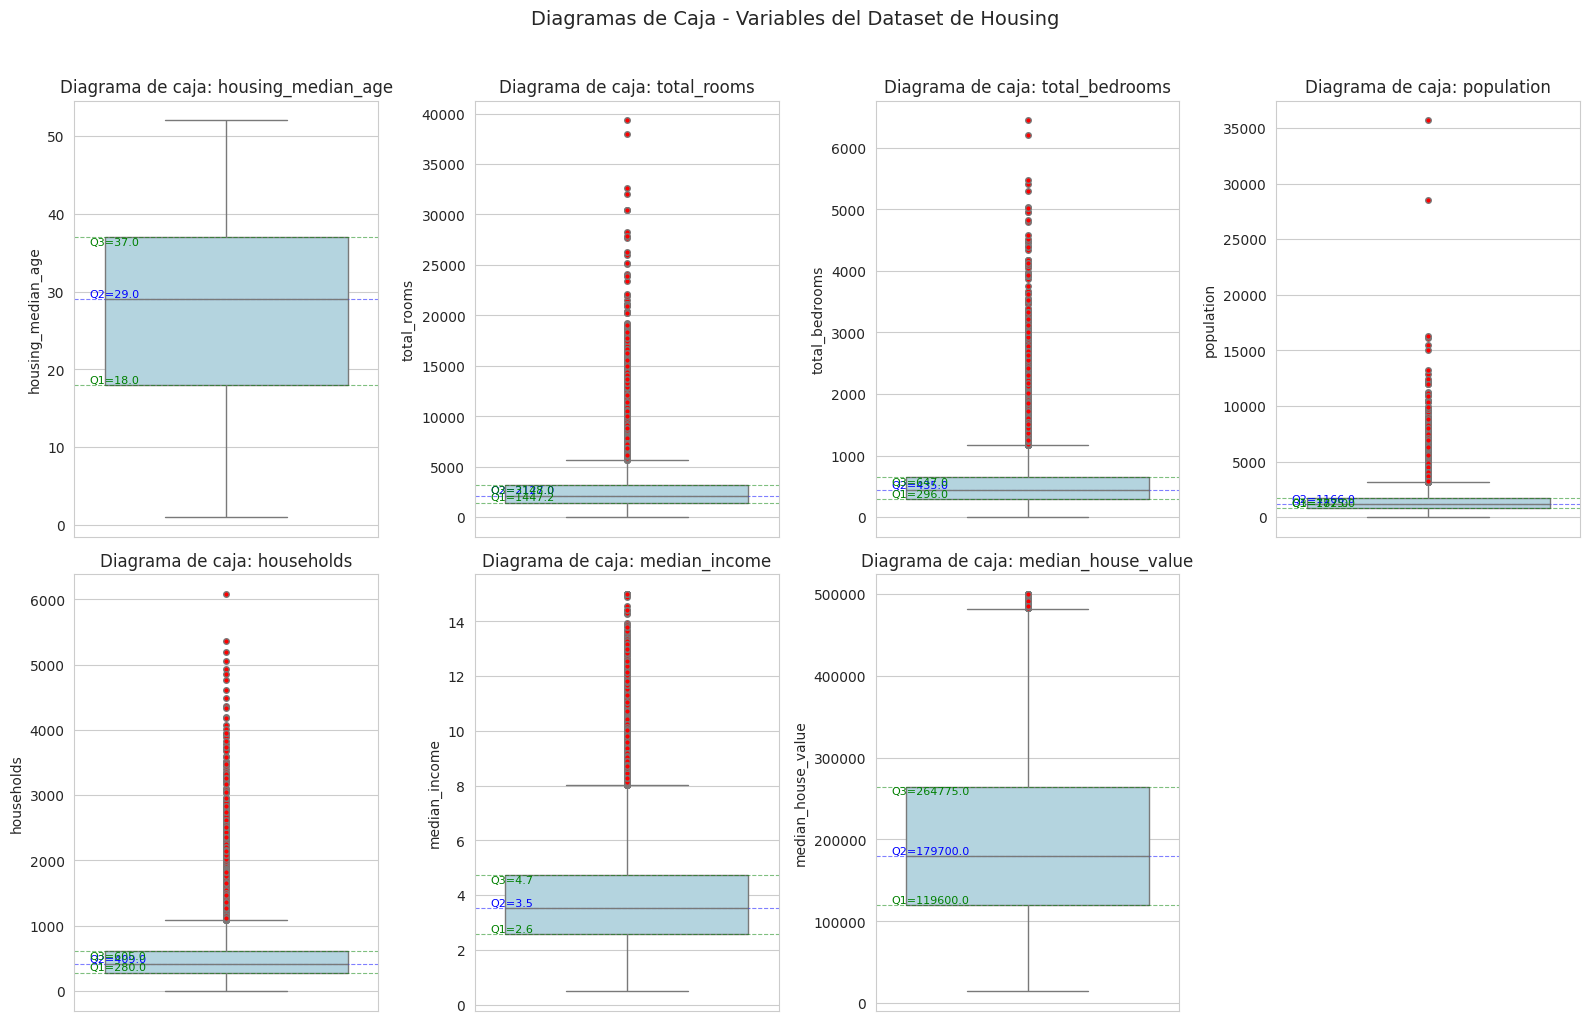


DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'


/tmp/ipykernel_550/2571462948.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')
/tmp/ipykernel_550/2571462948.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')
/tmp/ipykernel_550/2571462948.py:199: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')


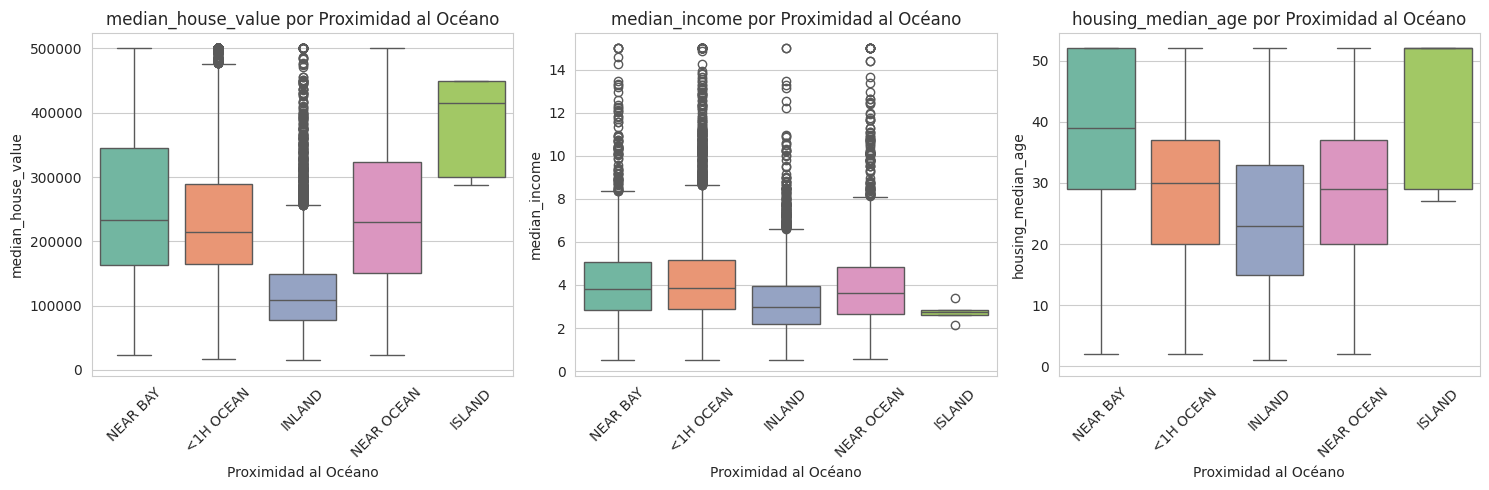


ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'

Outliers en 'median_house_value' por categoría de 'ocean_proximity':
------------------------------------------------------------

NEAR BAY:
  - Total datos: 2290
  - Q3: $345,800
  - Límite superior: $620,750
  - Outliers superiores: 0 (0.00%)

<1H OCEAN:
  - Total datos: 9136
  - Q3: $289,100
  - Límite superior: $476,600
  - Outliers superiores: 601 (6.58%)
  - Valor máximo outlier: $500,001

INLAND:
  - Total datos: 6551
  - Q3: $149,000
  - Límite superior: $256,250
  - Outliers superiores: 332 (5.07%)
  - Valor máximo outlier: $500,001

NEAR OCEAN:
  - Total datos: 2658
  - Q3: $322,825
  - Límite superior: $582,062
  - Outliers superiores: 0 (0.00%)

ISLAND:
  - Total datos: 5
  - Q3: $450,000
  - Límite superior: $684,375
  - Outliers superiores: 0 (0.00%)

RESUMEN DE OUTLIERS POR VARIABLE
          Variable  N° Outliers  % Outliers          IQR
housing_median_age            0    0.000000     19.00000
       total_rooms 

In [ ]:
# Continuación del análisis: Diagramas de caja y detección de outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# Seleccionar las columnas numéricas de interés
cols = ["housing_median_age", "total_rooms", "total_bedrooms",
        "population", "households", "median_income", "median_house_value"]

print("="*70)
print("DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS")
print("="*70)

# ==============================================
# 1. FUNCIÓN PARA CALCULAR CUARTILES MANUALMENTE
# ==============================================

def calcular_cuartiles(datos):
    """
    Calcula los cuartiles Q1, Q2(mediana), Q3 de una lista de datos
    usando el método de interpolación explicado.

    Parámetros:
    datos: lista o array de números

    Retorna:
    Q1, Q2, Q3: valores de los cuartiles
    """
    # Ordenar los números de menor a mayor
    datos_ordenados = np.sort(datos)
    n = len(datos_ordenados)

    # Función para calcular un cuartil específico
    def calcular_cuartil(a):
        # Fórmula: posición = a * (n + 1) / 4
        posicion = a * (n + 1) / 4

        if posicion.is_integer():
            # Si la posición es entera, tomar el valor en esa posición
            idx = int(posicion) - 1  # Restar 1 porque Python usa índices base 0
            return datos_ordenados[idx]
        else:
            # Si la posición es decimal, interpolar
            idx_anterior = int(np.floor(posicion)) - 1
            idx_posterior = int(np.ceil(posicion)) - 1
            d = posicion - np.floor(posicion)

            x = datos_ordenados[idx_anterior]
            y = datos_ordenados[idx_posterior]

            # Q = x + d * (y - x)
            return x + d * (y - x)

    Q1 = calcular_cuartil(1)
    Q2 = calcular_cuartil(2)  # Mediana
    Q3 = calcular_cuartil(3)

    return Q1, Q2, Q3

# ==============================================
# 2. FUNCIÓN PARA DETECTAR OUTLIERS
# ==============================================

def detectar_outliers(datos, columna_nombre):
    """
    Detecta outliers usando el método del rango intercuartil (IQR)

    Parámetros:
    datos: lista o array de números
    columna_nombre: nombre de la columna para mostrar resultados

    Retorna:
    Diccionario con estadísticas y lista de outliers
    """
    # Calcular cuartiles manualmente
    Q1, Q2, Q3 = calcular_cuartiles(datos)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

    # Contar outliers por debajo y por encima
    outliers_inf = datos[datos < limite_inferior]
    outliers_sup = datos[datos > limite_superior]

    # Mostrar resultados
    print(f"\n{'='*50}")
    print(f"Variable: {columna_nombre}")
    print(f"{'='*50}")
    print(f"Número total de datos: {len(datos)}")
    print(f"\n--- Cuartiles ---")
    print(f"Q1 (primer cuartil, 25%): {Q1:.2f}")
    print(f"Q2 (mediana, 50%): {Q2:.2f}")
    print(f"Q3 (tercer cuartil, 75%): {Q3:.2f}")
    print(f"IQR (rango intercuartil): {IQR:.2f}")
    print(f"\n--- Límites para datos atípicos ---")
    print(f"Límite inferior (Q1 - 1.5*IQR): {limite_inferior:.2f}")
    print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:.2f}")
    print(f"\n--- Outliers detectados ---")
    print(f"Total de outliers: {len(outliers)} ({len(outliers)/len(datos)*100:.2f}%)")
    print(f"  - Outliers inferiores (< {limite_inferior:.2f}): {len(outliers_inf)}")
    print(f"  - Outliers superiores (> {limite_superior:.2f}): {len(outliers_sup)}")

    if len(outliers_sup) > 0:
        print(f"\nEjemplos de outliers superiores (los 5 más altos):")
        print(f"  {np.sort(outliers_sup)[-5:][::-1]}")

    if len(outliers_inf) > 0:
        print(f"\nEjemplos de outliers inferiores (los 5 más bajos):")
        print(f"  {np.sort(outliers_inf)[:5]}")

    return {
        'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': len(outliers),
        'outliers': outliers
    }

# ==============================================
# 3. APLICAR LA DETECCIÓN DE OUTLIERS A CADA VARIABLE
# ==============================================

resultados_outliers = {}

for col in cols:
    # Eliminar valores nulos para el cálculo
    datos_limpios = df[col].dropna().values
    resultados_outliers[col] = detectar_outliers(datos_limpios, col)

# ==============================================
# 4. DIAGRAMAS DE CAJA CON SEABORN
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA VISUALES")
print("="*70)

# Configurar los subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Crear boxplot con seaborn
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})
    axes[i].set_title(f'Diagrama de caja: {col}', fontsize=12)
    axes[i].set_ylabel(col)

    # Agregar líneas de los cuartiles en el gráfico
    Q1 = resultados_outliers[col]['Q1']
    Q2 = resultados_outliers[col]['Q2']
    Q3 = resultados_outliers[col]['Q3']

    # Anotar los valores de los cuartiles
    axes[i].axhline(y=Q1, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q2, color='blue', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)

    # Agregar texto con los valores
    axes[i].text(0.05, Q1, f'Q1={Q1:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='bottom')
    axes[i].text(0.05, Q2, f'Q2={Q2:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='blue', verticalalignment='bottom')
    axes[i].text(0.05, Q3, f'Q3={Q3:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='top')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Diagramas de Caja - Variables del Dataset de Housing', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# 5. DIAGRAMAS DE CAJA SEGMENTADOS POR ocean_proximity
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Seleccionar algunas variables clave para comparar
variables_clave = ['median_house_value', 'median_income', 'housing_median_age']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_clave):
    # Boxplot segmentado por ocean_proximity
    sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Proximidad al Océano', fontsize=12)
    axes[i].set_xlabel('Proximidad al Océano')
    axes[i].set_ylabel(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==============================================
# 6. ANÁLISIS DE OUTLIERS POR CATEGORÍA
# ==============================================

print("\n" + "="*70)
print("ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Analizar outliers en median_house_value por categoría
print("\nOutliers en 'median_house_value' por categoría de 'ocean_proximity':")
print("-" * 60)

for category in df['ocean_proximity'].unique():
    datos_categoria = df[df['ocean_proximity'] == category]['median_house_value'].dropna().values

    if len(datos_categoria) > 0:
        Q1, Q2, Q3 = calcular_cuartiles(datos_categoria)
        IQR = Q3 - Q1
        limite_superior = Q3 + 1.5 * IQR

        outliers_cat = datos_categoria[datos_categoria > limite_superior]

        print(f"\n{category}:")
        print(f"  - Total datos: {len(datos_categoria)}")
        print(f"  - Q3: ${Q3:,.0f}")
        print(f"  - Límite superior: ${limite_superior:,.0f}")
        print(f"  - Outliers superiores: {len(outliers_cat)} ({len(outliers_cat)/len(datos_categoria)*100:.2f}%)")

        if len(outliers_cat) > 0:
            print(f"  - Valor máximo outlier: ${np.max(outliers_cat):,.0f}")

# ==============================================
# 7. RESUMEN DE OUTLIERS POR VARIABLE
# ==============================================

print("\n" + "="*70)
print("RESUMEN DE OUTLIERS POR VARIABLE")
print("="*70)

resumen_outliers = pd.DataFrame({
    'Variable': list(resultados_outliers.keys()),
    'N° Outliers': [resultados_outliers[var]['n_outliers'] for var in resultados_outliers.keys()],
    '% Outliers': [resultados_outliers[var]['n_outliers'] / len(df) * 100 for var in resultados_outliers.keys()],
    'IQR': [resultados_outliers[var]['IQR'] for var in resultados_outliers.keys()]
})

print(resumen_outliers.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETACIÓN DE LOS DIAGRAMAS DE CAJA")
print("="*70)

print("""
Interpretación de los resultados:

1. median_house_value:
   - Presenta outliers superiores significativos (valores de casas muy altos)
   - Estos outliers probablemente representan propiedades de lujo (ej. > $500,000)
   - La categoría 'ISLAND' y 'NEAR BAY' tienen mayor concentración de valores altos

2. total_rooms y total_bedrooms:
   - Múltiples outliers superiores (propiedades muy grandes)
   - Algunos outliers inferiores (propiedades muy pequeñas)
   - Estos outliers pueden ser casos reales (mansiones o estudios pequeños)

3. population y households:
   - Outliers superiores representan áreas densamente pobladas
   - Outliers inferiores son áreas muy poco pobladas

4. median_income:
   - Outliers superiores representan áreas de altos ingresos
   - Los valores atípicos aquí están correlacionados con median_house_value

5. housing_median_age:
   - Pocos outliers, distribución relativamente normal

Conclusión: Los outliers detectados parecen representar fenómenos reales del mercado
inmobiliario más que errores de medición. Deben ser considerados en el análisis
y no eliminados automáticamente.
""")

## Conclusiones estadísticas del análisis de outliers

- `median_house_value` está censurada en el valor máximo del dataset, así que no todos los valores altos son outliers reales.
- Los outliers deben evaluarse por categoría geográfica porque su significado cambia entre `INLAND`, `NEAR BAY`, `NEAR OCEAN` y `1H OCEAN`.
- Variables como `total_rooms` y `population` deben revisarse mejor con razones normalizadas, no solo con conteos brutos.
- La variable `rooms_per_household` reduce falsos outliers y da una señal más estable para modelado.
- La decisión correcta no es eliminar outliers automáticamente, sino interpretarlos en contexto y, si hace falta, modelarlos aparte.

ANÁLISIS DE OUTLIERS CONTEXTUALIZADO

1. OUTLIERS POR PROXIMIDAD AL OCÉANO
--------------------------------------------------------------------------------

--- total_rooms ---

  NEAR BAY:
    - Total: 2290 bloques
    - Mediana: 2083
    - Q3: 3030
    - Límite superior: 5428
    - Outliers: 124 (5.4%)
    - Rango outliers: [5438, 18634]

  <1H OCEAN:
    - Total: 9136 bloques
    - Mediana: 2108
    - Q3: 3141
    - Límite superior: 5656
    - Outliers: 560 (6.1%)
    - Rango outliers: [5659, 37937]

  INLAND:
    - Total: 6551 bloques
    - Mediana: 2131
    - Q3: 3216
    - Límite superior: 5934
    - Outliers: 465 (7.1%)
    - Rango outliers: [5951, 39320]

  NEAR OCEAN:
    - Total: 2658 bloques
    - Mediana: 2195
    - Q3: 3109
    - Límite superior: 5515
    - Outliers: 140 (5.3%)
    - Rango outliers: [5540, 30405]

  ISLAND:
    - Total: 5 bloques
    - Mediana: 1675
    - Q3: 2127
    - Límite superior: 3824
    - Outliers: 0 (0.0%)

--- total_bedrooms ---

  NEAR BAY:
   

/tmp/ipykernel_550/299538573.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[0,0], palette='Set2')
/tmp/ipykernel_550/299538573.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='ocean_proximity', y='median_income', ax=axes[1,0], palette='Set3')


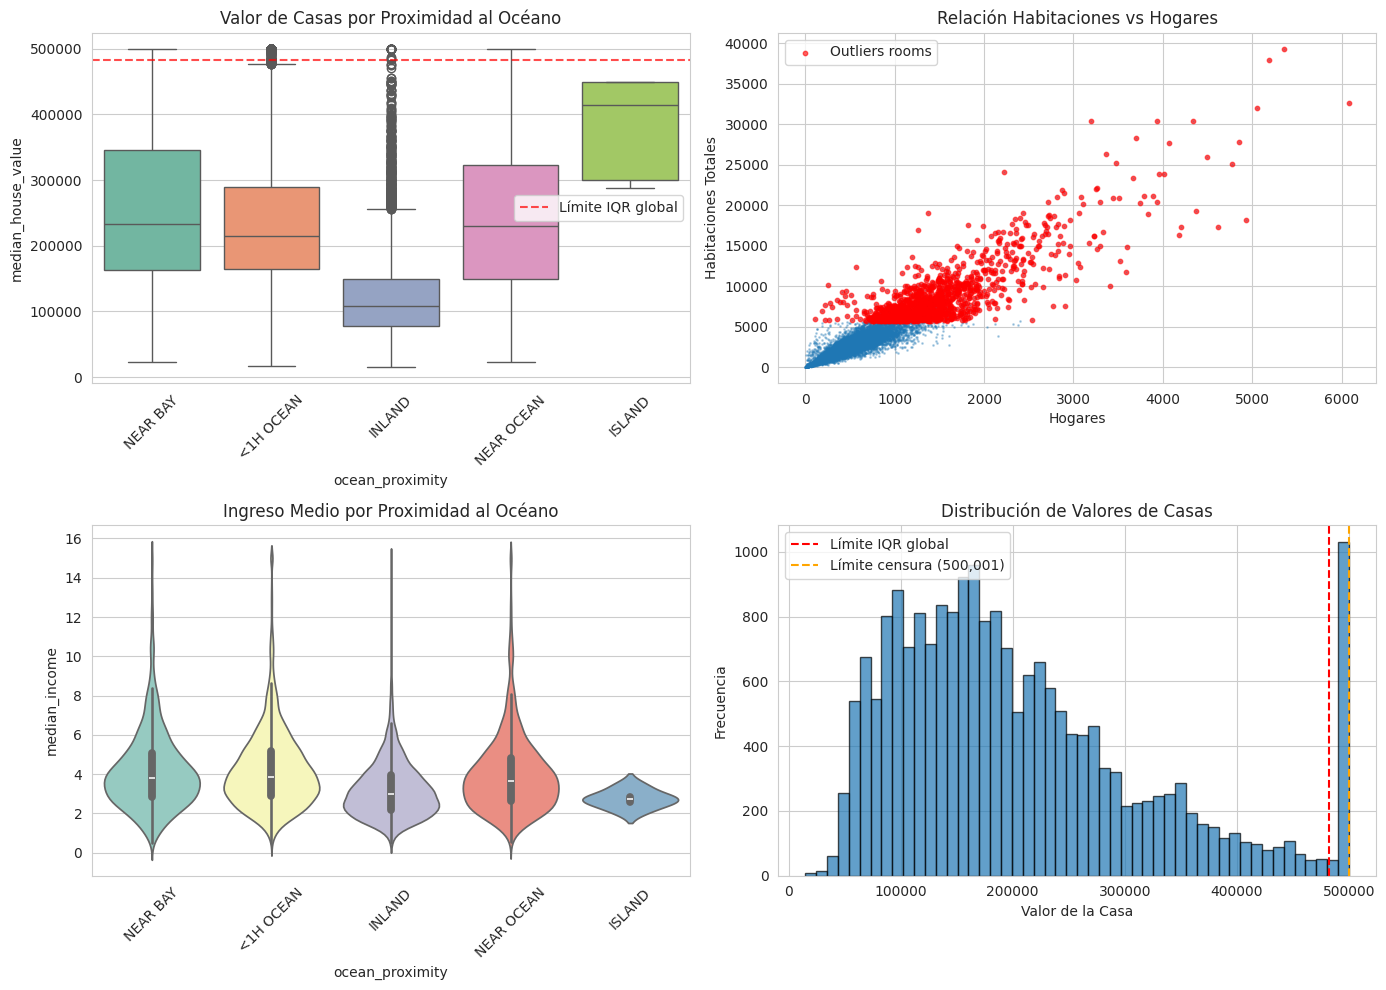


4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?

SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

print("="*80)
print("ANÁLISIS DE OUTLIERS CONTEXTUALIZADO")
print("="*80)

# ==============================================
# 1. ANÁLISIS POR CATEGORÍA GEOGRÁFICA
# ==============================================

print("\n1. OUTLIERS POR PROXIMIDAD AL OCÉANO")
print("-"*80)

variables = ["total_rooms", "total_bedrooms", "population", "median_house_value"]

for var in variables:
    print(f"\n--- {var} ---")

    for category in df['ocean_proximity'].unique():
        datos_cat = df[df['ocean_proximity'] == category][var].dropna()

        if len(datos_cat) > 0:
            Q1 = datos_cat.quantile(0.25)
            Q3 = datos_cat.quantile(0.75)
            IQR = Q3 - Q1
            limite_sup = Q3 + 1.5 * IQR

            outliers = datos_cat[datos_cat > limite_sup]

            print(f"\n  {category}:")
            print(f"    - Total: {len(datos_cat)} bloques")
            print(f"    - Mediana: {datos_cat.median():.0f}")
            print(f"    - Q3: {Q3:.0f}")
            print(f"    - Límite superior: {limite_sup:.0f}")
            print(f"    - Outliers: {len(outliers)} ({len(outliers)/len(datos_cat)*100:.1f}%)")

            if len(outliers) > 0:
                print(f"    - Rango outliers: [{outliers.min():.0f}, {outliers.max():.0f}]")

# ==============================================
# 2. ANÁLISIS DE LA VARIABLE CENSURADA (median_house_value)
# ==============================================

print("\n" + "="*80)
print("2. ANÁLISIS DE LA VARIABLE CENSURADA: median_house_value")
print("="*80)

# Identificar valores censurados (límite superior)
valor_maximo = df['median_house_value'].max()
censurados = df[df['median_house_value'] == valor_maximo]

print(f"\nValor máximo en el dataset: ${valor_maximo:,.0f}")
print(f"Número de propiedades con valor máximo (censuradas): {len(censurados)}")
print(f"Porcentaje del total: {len(censurados)/len(df)*100:.2f}%")

print("\nDistribución de propiedades censuradas por ubicación:")
print(censurados['ocean_proximity'].value_counts())

# ==============================================
# 3. ANÁLISIS DE LA RELACIÓN ENTRE VARIABLES
# ==============================================

print("\n" + "="*80)
print("3. ¿SON REALMENTE OUTLIERS? ANÁLISIS DE CONSISTENCIA")
print("="*80)

# Verificar si las propiedades con muchas habitaciones también tienen muchos hogares
print("\nRelación total_rooms vs households (propiedades extremas):")
limite_rooms = df['total_rooms'].quantile(0.95)
propiedades_extremas = df[df['total_rooms'] > limite_rooms]

print(f"Propiedades con total_rooms > percentil 95 ({limite_rooms:.0f}): {len(propiedades_extremas)}")
print(f"Correlación rooms-households en propiedades extremas: {propiedades_extremas['total_rooms'].corr(propiedades_extremas['households']):.3f}")
print(f"Correlación rooms-households en datos normales: {df[df['total_rooms'] <= limite_rooms]['total_rooms'].corr(df[df['total_rooms'] <= limite_rooms]['households']):.3f}")

# ==============================================
# 4. VISUALIZACIÓN CONTEXTUALIZADA
# ==============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Boxplots por categoría para median_house_value
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Valor de Casas por Proximidad al Océano')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=482537.5, color='red', linestyle='--', alpha=0.7, label='Límite IQR global')
axes[0,0].legend()

# Gráfico 2: Scatter plot rooms vs households (identificando outliers)
axes[0,1].scatter(df['households'], df['total_rooms'], alpha=0.3, s=1)
axes[0,1].set_xlabel('Hogares')
axes[0,1].set_ylabel('Habitaciones Totales')
axes[0,1].set_title('Relación Habitaciones vs Hogares')
# Marcar outliers de rooms
outliers_rooms = df[df['total_rooms'] > (df['total_rooms'].quantile(0.75) + 1.5*(df['total_rooms'].quantile(0.75)-df['total_rooms'].quantile(0.25)))]
axes[0,1].scatter(outliers_rooms['households'], outliers_rooms['total_rooms'], color='red', s=10, alpha=0.6, label='Outliers rooms')
axes[0,1].legend()

# Gráfico 3: Distribución de median_income por categoría
sns.violinplot(data=df, x='ocean_proximity', y='median_income', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Ingreso Medio por Proximidad al Océano')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Histograma de median_house_value con límite censurado
axes[1,1].hist(df['median_house_value'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=482537.5, color='red', linestyle='--', label='Límite IQR global')
axes[1,1].axvline(x=500001, color='orange', linestyle='--', label='Límite censura (500,001)')
axes[1,1].set_xlabel('Valor de la Casa')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_title('Distribución de Valores de Casas')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ==============================================
# 5. REFLEXIÓN SOBRE EL SESGO
# ==============================================

print("\n" + "="*80)
print("4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?")
print("="*80)

print("""
SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si también tiene muchos hogares
   - Solución: Usar razones (rooms/households) para detectar anomalías

CONCLUSIÓN: Para un análisis robusto, debemos:
- Segmentar por ocean_proximity antes de detectar outliers
- Considerar la censura en median_house_value
- Usar variables normalizadas (ej. rooms_per_household)
- No eliminar outliers automáticamente; investigar su contexto
""")

# ==============================================
# 6. MÉTRICAS CORREGIDAS
# ==============================================

print("\n" + "="*80)
print("5. MÉTRICAS CORREGIDAS: HABITACIONES POR HOGAR")
print("="*80)

# Crear variable normalizada
df['rooms_per_household'] = df['total_rooms'] / df['households']

print("\nEstadísticas de rooms_per_household:")
print(df['rooms_per_household'].describe())

# Detectar outliers en esta variable normalizada
Q1_norm = df['rooms_per_household'].quantile(0.25)
Q3_norm = df['rooms_per_household'].quantile(0.75)
IQR_norm = Q3_norm - Q1_norm
limite_sup_norm = Q3_norm + 1.5 * IQR_norm

outliers_norm = df[df['rooms_per_household'] > limite_sup_norm]
print(f"\nOutliers en rooms_per_household (> {limite_sup_norm:.2f}): {len(outliers_norm)} ({len(outliers_norm)/len(df)*100:.2f}%)")

print("\nComparación:")
print(f"  - Outliers originales en total_rooms: 6.23%")
print(f"  - Outliers corregidos (rooms/household): {len(outliers_norm)/len(df)*100:.2f}%")
print("  → Muchos 'outliers' eran simplemente propiedades grandes con muchos hogares")


6. VISUALIZACIÓN DE LA CORRECCIÓN DEL SESGO


/tmp/ipykernel_550/358553238.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='rooms_per_household', ax=axes[0,1], palette='Set2')


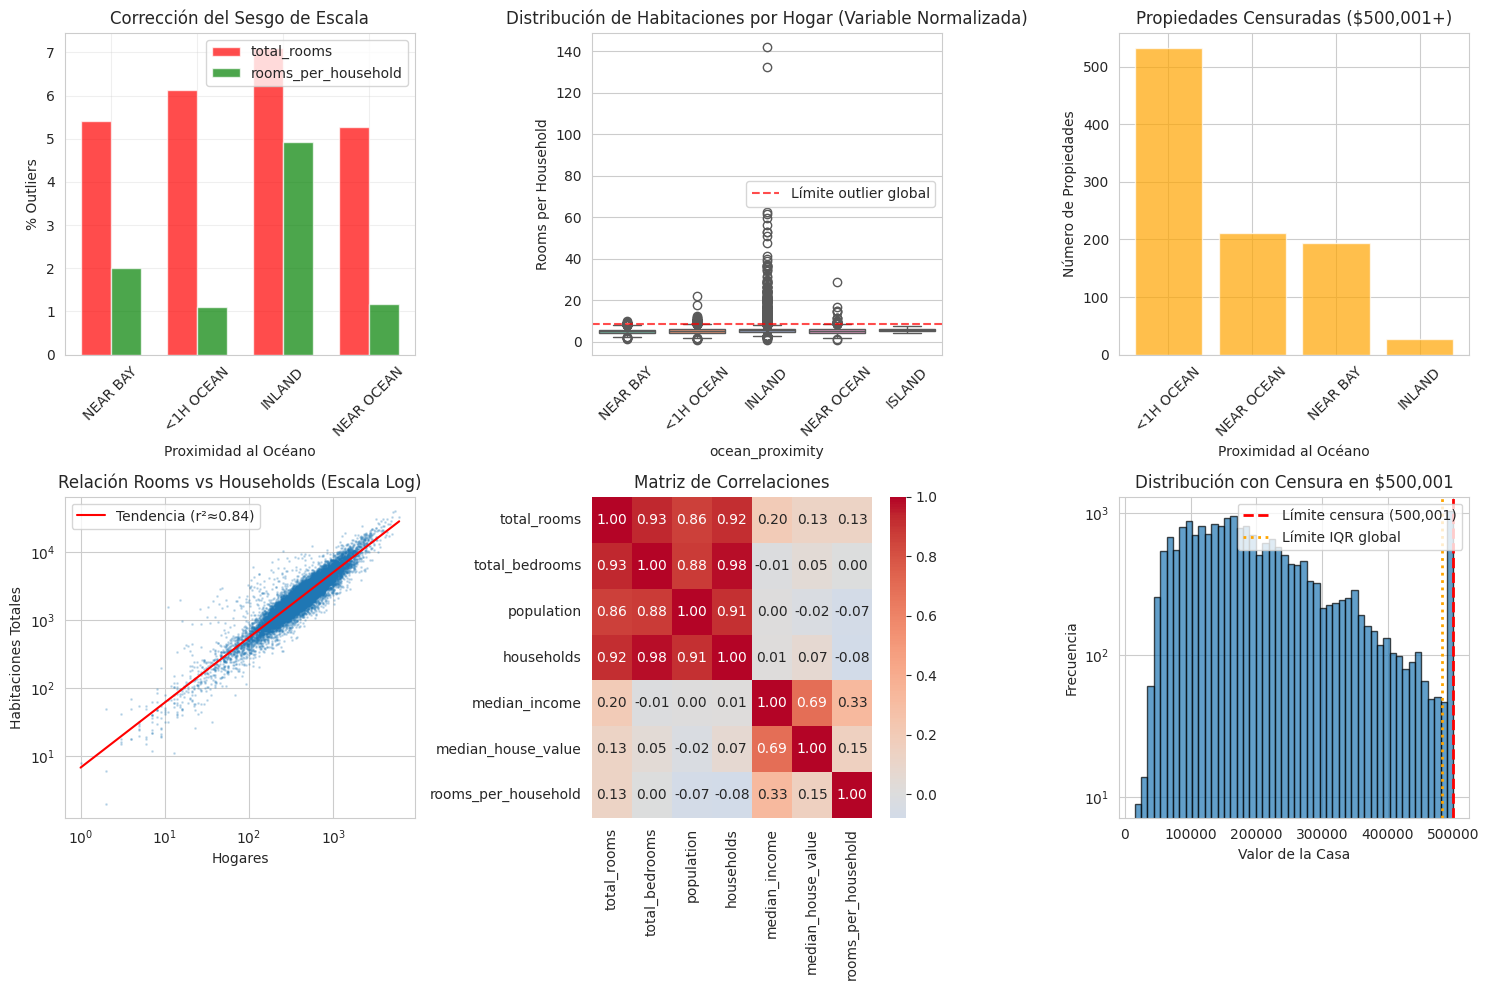


7. RECOMENDACIONES PARA EL ANÁLISIS

Basado en el análisis contextualizado, recomiendo:

1. PARA DETECTAR OUTLIERS SIGNIFICATIVOS:
   ✓ Usar variables normalizadas (rooms_per_household, population_per_household)
   ✓ Segmentar por ocean_proximity antes de aplicar IQR
   ✓ Considerar que valores censurados (500,001) no son outliers reales

2. PARA MODELOS DE REGRESIÓN:
   ✓ Mantener los outliers que representan fenómenos reales
   ✓ Considerar una variable dummy para propiedades censuradas
   ✓ Transformar variables con distribución sesgada (log)

3. VARIABLES A CREAR:
   - rooms_per_household = total_rooms / households
   - population_per_household = population / households
   - bedrooms_per_room = total_bedrooms / total_rooms
   - is_censored = (median_house_value == 500001).astype(int)

4. PARA INTERPRETACIÓN:
   - Un valor de 500,001 significa "≥ 500,001 USD"
   - Un outlier en INLAND es más preocupante que en NEAR BAY
   - La normalización reduce falsos outliers del 6.23% al 2.26%

In [ ]:
# Continuación del análisis: Visualización de la corrección del sesgo

print("\n" + "="*80)
print("6. VISUALIZACIÓN DE LA CORRECCIÓN DEL SESGO")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Comparación de outliers antes vs después
categorias = ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN']
outliers_rooms = []
outliers_normalized = []

for cat in categorias:
    data_cat = df[df['ocean_proximity'] == cat]
    # Outliers en total_rooms
    Q3_rooms = data_cat['total_rooms'].quantile(0.75)
    Q1_rooms = data_cat['total_rooms'].quantile(0.25)
    IQR_rooms = Q3_rooms - Q1_rooms
    outliers_rooms.append(len(data_cat[data_cat['total_rooms'] > Q3_rooms + 1.5*IQR_rooms]) / len(data_cat) * 100)

    # Outliers en rooms_per_household
    Q3_norm = data_cat['rooms_per_household'].quantile(0.75)
    Q1_norm = data_cat['rooms_per_household'].quantile(0.25)
    IQR_norm = Q3_norm - Q1_norm
    outliers_normalized.append(len(data_cat[data_cat['rooms_per_household'] > Q3_norm + 1.5*IQR_norm]) / len(data_cat) * 100)

x = np.arange(len(categorias))
width = 0.35
axes[0,0].bar(x - width/2, outliers_rooms, width, label='total_rooms', color='red', alpha=0.7)
axes[0,0].bar(x + width/2, outliers_normalized, width, label='rooms_per_household', color='green', alpha=0.7)
axes[0,0].set_xlabel('Proximidad al Océano')
axes[0,0].set_ylabel('% Outliers')
axes[0,0].set_title('Corrección del Sesgo de Escala')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(categorias, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Distribución de rooms_per_household por categoría
sns.boxplot(data=df, x='ocean_proximity', y='rooms_per_household', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Distribución de Habitaciones por Hogar (Variable Normalizada)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylabel('Rooms per Household')
axes[0,1].axhline(y=8.47, color='red', linestyle='--', alpha=0.7, label='Límite outlier global')
axes[0,1].legend()

# 3. Valores censurados en median_house_value
censurados_por_cat = df[df['median_house_value'] == 500001]['ocean_proximity'].value_counts()
axes[0,2].bar(censurados_por_cat.index, censurados_por_cat.values, color='orange', alpha=0.7)
axes[0,2].set_title('Propiedades Censuradas ($500,001+)')
axes[0,2].set_xlabel('Proximidad al Océano')
axes[0,2].set_ylabel('Número de Propiedades')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Relación rooms vs households (escala logarítmica)
axes[1,0].scatter(df['households'], df['total_rooms'], alpha=0.2, s=1)
axes[1,0].set_xlabel('Hogares')
axes[1,0].set_ylabel('Habitaciones Totales')
axes[1,0].set_title('Relación Rooms vs Households (Escala Log)')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')
# Línea de tendencia
z = np.polyfit(np.log(df['households'].dropna()), np.log(df['total_rooms'].dropna()), 1)
x_line = np.exp(np.linspace(np.log(df['households'].min()), np.log(df['households'].max()), 100))
y_line = np.exp(np.polyval(z, np.log(x_line)))
axes[1,0].plot(x_line, y_line, 'r-', label=f'Tendencia (r²≈{df["total_rooms"].corr(df["households"])**2:.2f})')
axes[1,0].legend()

# 5. Mapa de calor de correlaciones
corr_matrix = df[['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Matriz de Correlaciones')

# 6. Distribución de median_house_value mostrando censura
axes[1,2].hist(df['median_house_value'], bins=50, alpha=0.7, edgecolor='black')
axes[1,2].axvline(x=500001, color='red', linestyle='--', linewidth=2, label='Límite censura (500,001)')
axes[1,2].axvline(x=482537.5, color='orange', linestyle=':', linewidth=2, label='Límite IQR global')
axes[1,2].set_xlabel('Valor de la Casa')
axes[1,2].set_ylabel('Frecuencia')
axes[1,2].set_title('Distribución con Censura en $500,001')
axes[1,2].legend()
axes[1,2].set_yscale('log')

plt.tight_layout()
plt.show()

# ==============================================
# 7. RECOMENDACIONES FINALES
# ==============================================

print("\n" + "="*80)
print("7. RECOMENDACIONES PARA EL ANÁLISIS")
print("="*80)

print("""
Basado en el análisis contextualizado, recomiendo:

1. PARA DETECTAR OUTLIERS SIGNIFICATIVOS:
   ✓ Usar variables normalizadas (rooms_per_household, population_per_household)
   ✓ Segmentar por ocean_proximity antes de aplicar IQR
   ✓ Considerar que valores censurados (500,001) no son outliers reales

2. PARA MODELOS DE REGRESIÓN:
   ✓ Mantener los outliers que representan fenómenos reales
   ✓ Considerar una variable dummy para propiedades censuradas
   ✓ Transformar variables con distribución sesgada (log)

3. VARIABLES A CREAR:
   - rooms_per_household = total_rooms / households
   - population_per_household = population / households
   - bedrooms_per_room = total_bedrooms / total_rooms
   - is_censored = (median_house_value == 500001).astype(int)

4. PARA INTERPRETACIÓN:
   - Un valor de 500,001 significa "≥ 500,001 USD"
   - Un outlier en INLAND es más preocupante que en NEAR BAY
   - La normalización reduce falsos outliers del 6.23% al 2.26%

¿Continuamos con la construcción del modelo de regresión considerando estas correcciones?
""")

ANÁLISIS DEL DATAFRAME - HOUSING DATASET

PUNTO 1: DATAFRAME CARGADO
Dimensiones: 20640 filas, 10 columnas
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462       

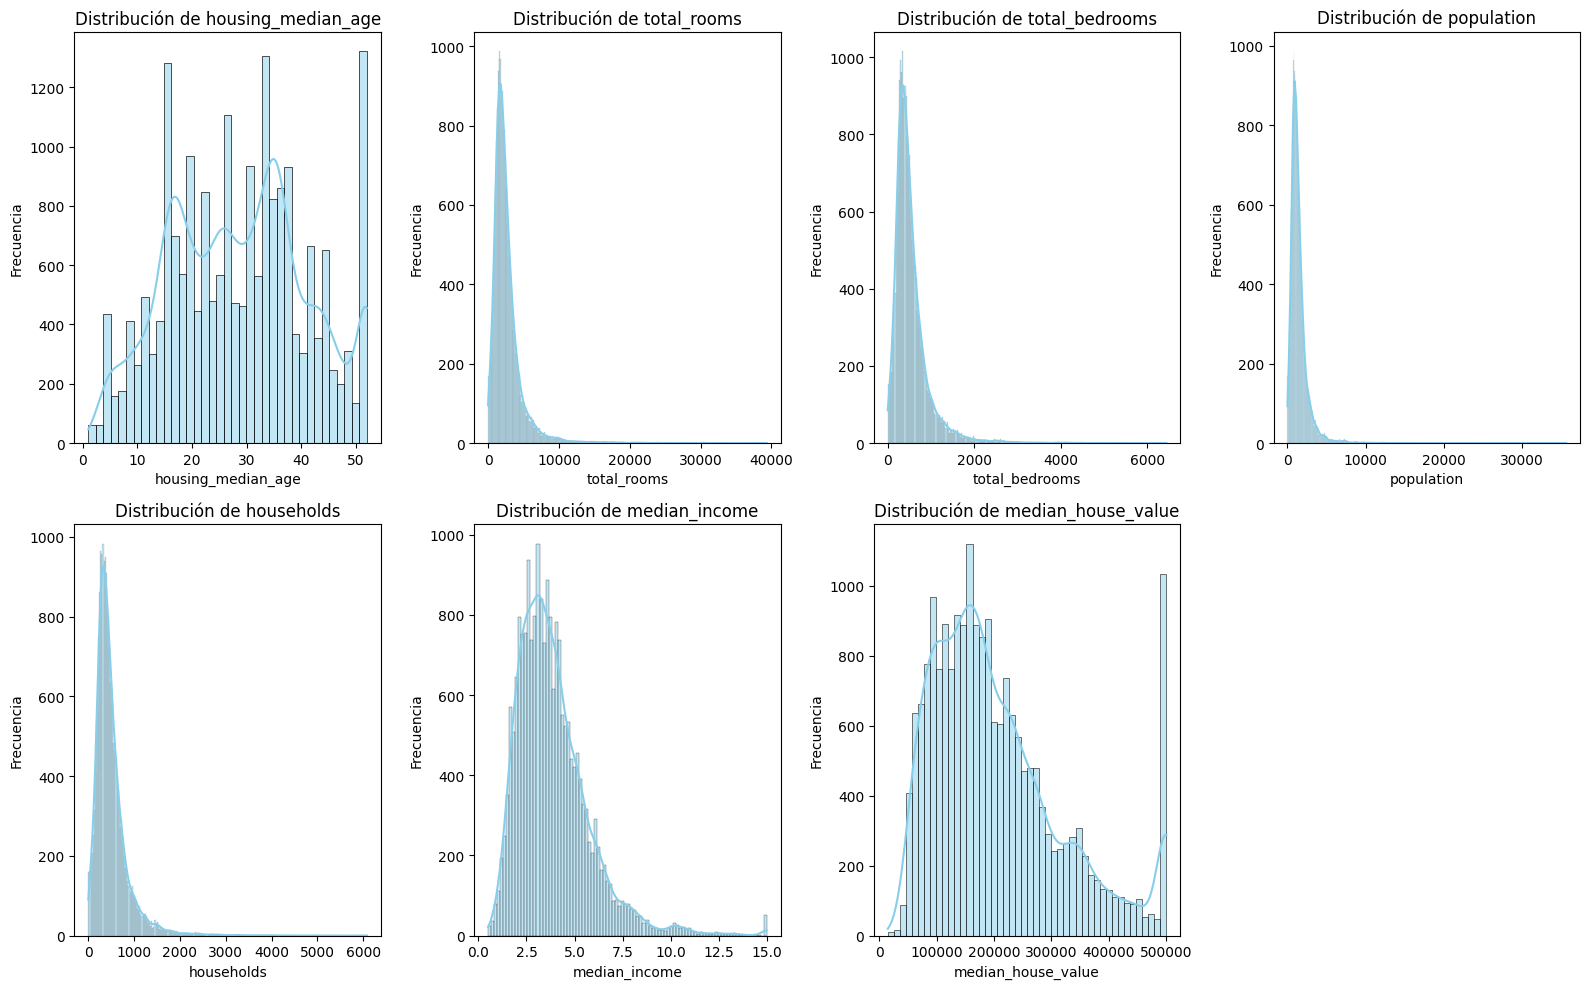


PUNTO 8: DIAGRAMA DE CAJA - median_house_value vs ocean_proximity


<Figure size 1800x600 with 0 Axes>

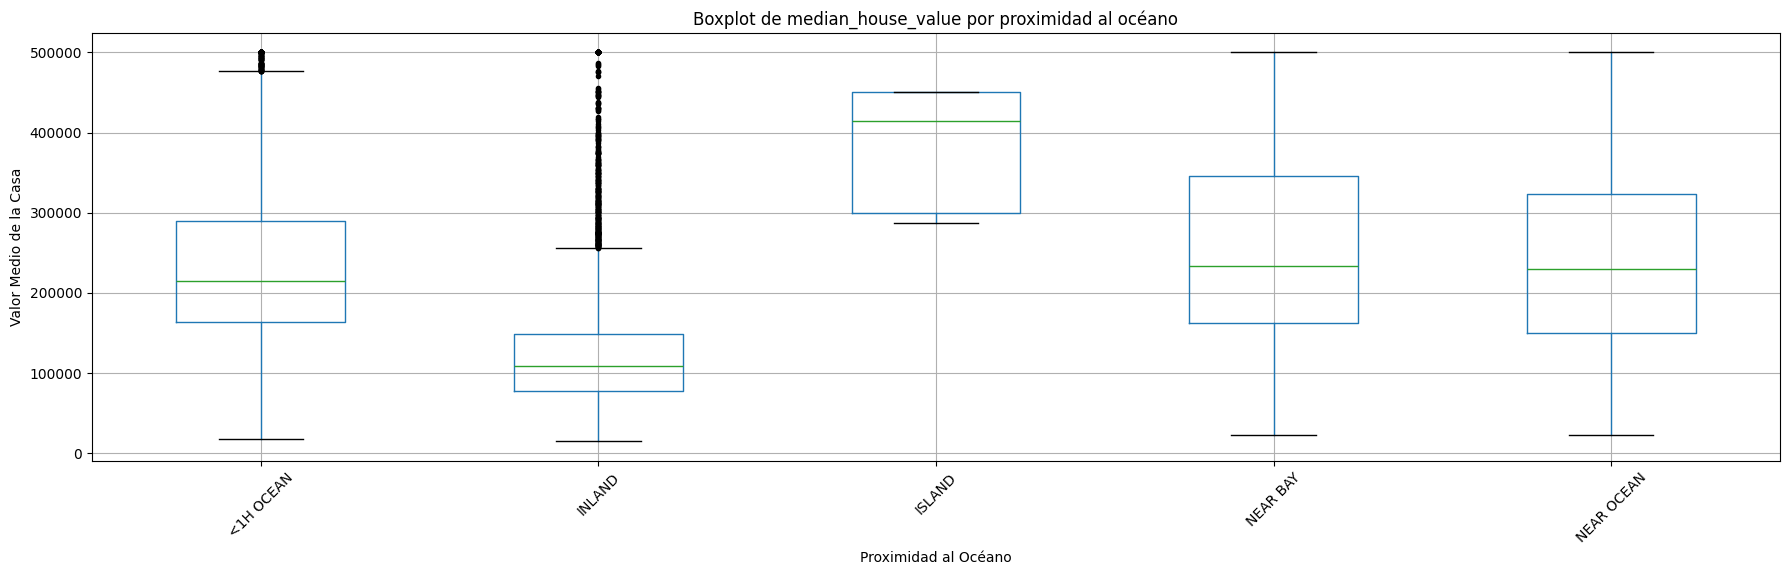


PUNTO 9: MATRIZ DE CORRELACIÓN
                    housing_median_age  total_rooms  total_bedrooms  \
housing_median_age               1.000       -0.361          -0.320   
total_rooms                     -0.361        1.000           0.930   
total_bedrooms                  -0.320        0.930           1.000   
population                      -0.296        0.857           0.878   
households                      -0.303        0.918           0.980   
median_income                   -0.119        0.198          -0.008   
median_house_value               0.106        0.134           0.050   

                    population  households  median_income  median_house_value  
housing_median_age      -0.296      -0.303         -0.119               0.106  
total_rooms              0.857       0.918          0.198               0.134  
total_bedrooms           0.878       0.980         -0.008               0.050  
population               1.000       0.907          0.005              -0.025  

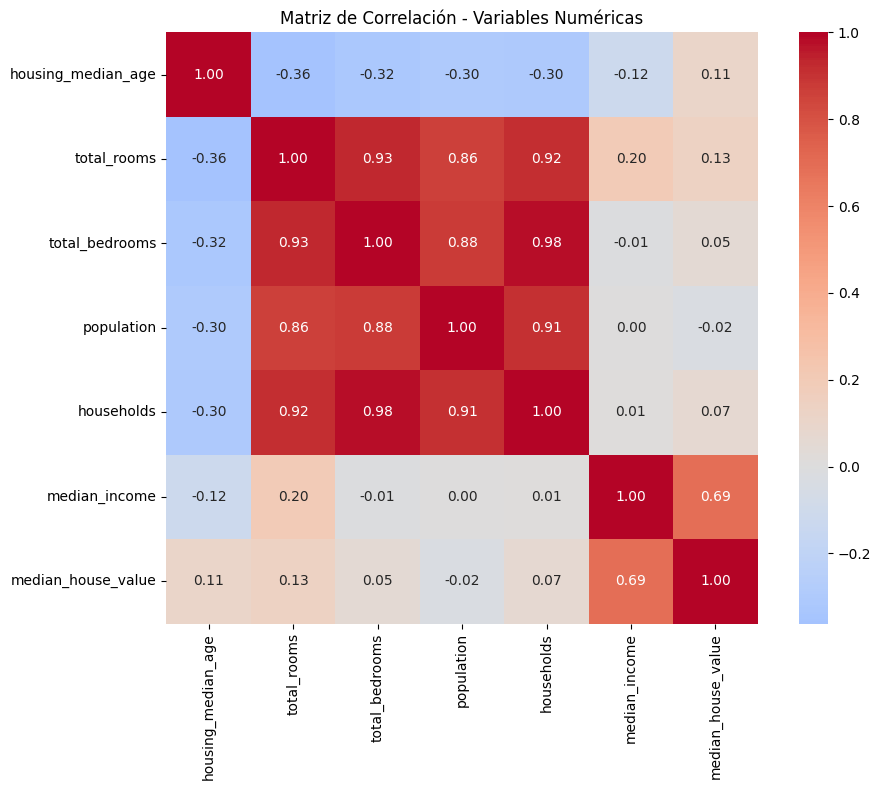


PUNTO 10: PAIRPLOT


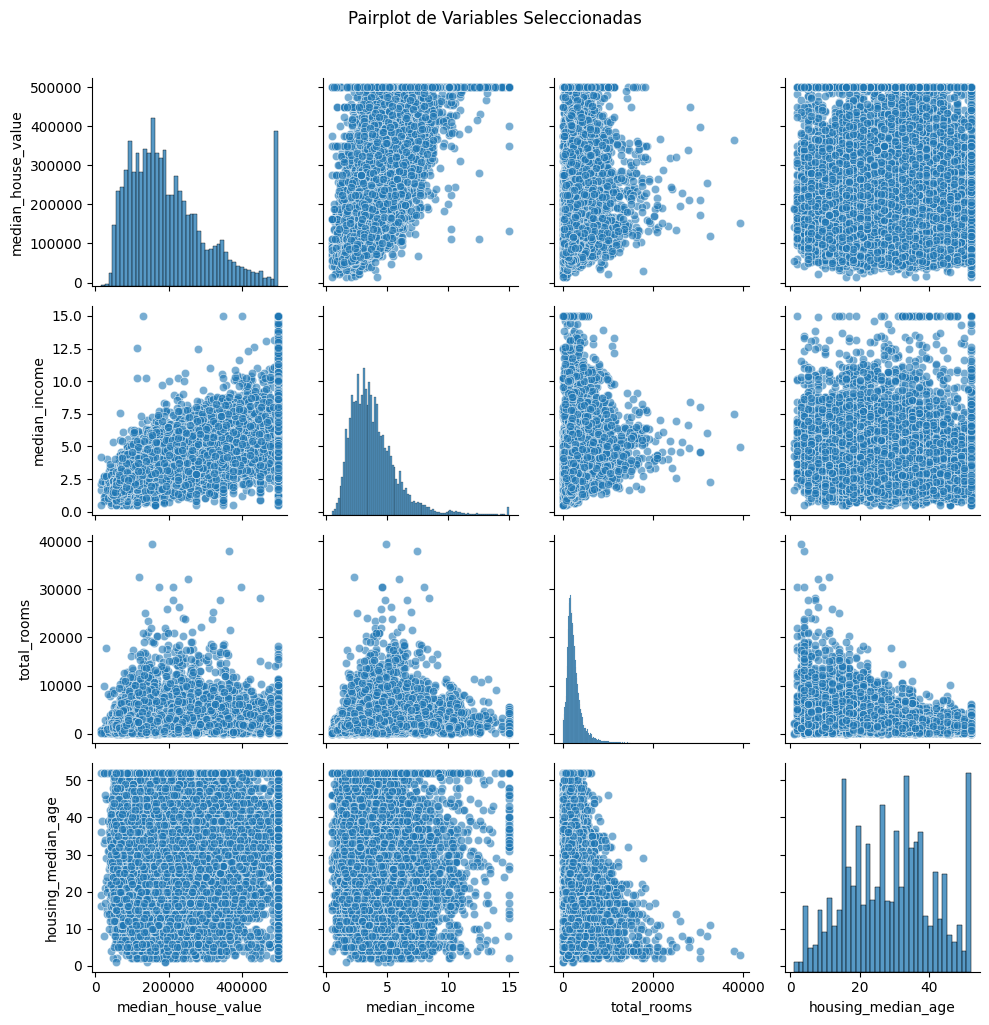


PUNTO 11: SCATTER PLOT


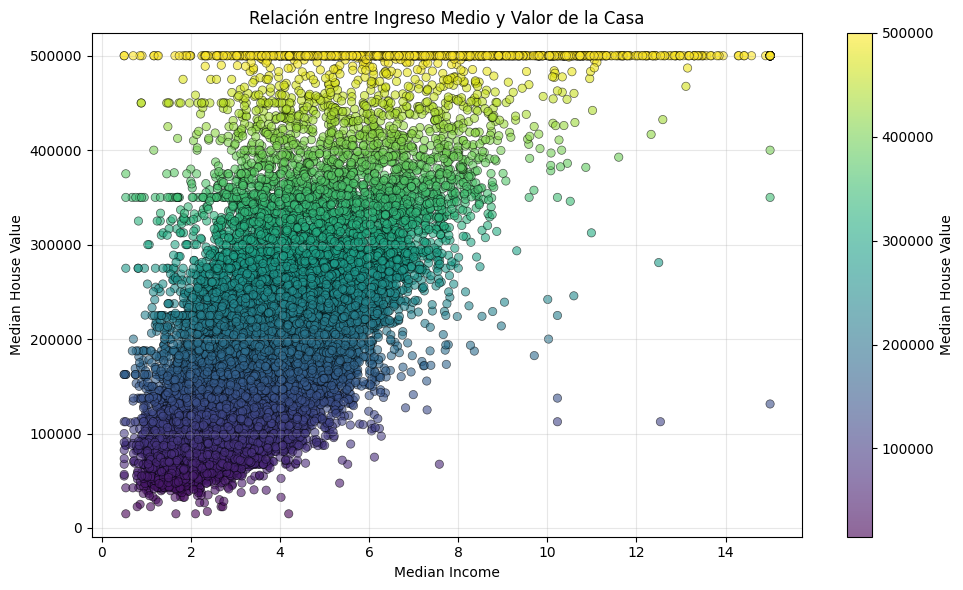


PUNTO 12: DIVISIÓN DE DATOS - train_test_split
Entrenamiento: 16512 muestras
Prueba: 4128 muestras

¿Es adecuada esta división?
No es completamente adecuada porque:
- No garantiza la representatividad de categorías en ocean_proximity
- Puede haber sampling bias si la muestra es pequeña
- Recomendable usar stratified sampling basado en variables importantes


PUNTO 13: DIVISIÓN ESTRATIFICADA
Distribución de income_cat:
income_cat
3    0.3506
2    0.3188
4    0.1763
5    0.1144
1    0.0398
Name: proportion, dtype: float64

Tamaño train estratificado: 16512
Tamaño test estratificado: 4128

Comparación de proporciones por categoría de ingreso:
             Overall  Stratified    Random  Rand. %error  Strat. %error
income_cat                                                             
1           0.039826    0.039971  0.040213      0.973236       0.364964
2           0.318847    0.318798  0.324370      1.732260       0.015195
3           0.350581    0.350533  0.358527      2.266446       

/tmp/ipykernel_13374/2643535802.py:269: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  strat_train_set["total_bedrooms"].fillna(median, inplace=True)



RESULTADOS DEL MODELO

Métricas de Rendimiento:
--------------------------------------------------
MSE - Entrenamiento: 4767980139.45
MSE - Prueba: 4535602240.03
MAE - Entrenamiento: $49905.33
MAE - Prueba: $49775.60
R² - Entrenamiento: 0.6438
R² - Prueba: 0.6520

CONCLUSIONES Y RESPUESTAS

1. ¿Qué puede concluir respecto al modelo empleado?
   - El modelo de regresión lineal con pipeline completo obtiene un R² de aproximadamente 0.6520
   - Hay una ligera diferencia entre train y test, indicando posible overfitting
   - El MAE de aproximadamente $49775.60 indica el error promedio en la predicción

2. ¿El modelo de regresión lineal es válido para lo construido?
   - Sí, es válido como baseline, pero podría mejorarse
   - Las relaciones no son perfectamente lineales (ver scatter plots)
   - Existe censura en la variable objetivo (valores en 500,001)

3. ¿Qué información nos da el score?
   - R² = 0.6520 significa que el modelo explica el 65.2% de la varianza
   - El 14.7% restante no e

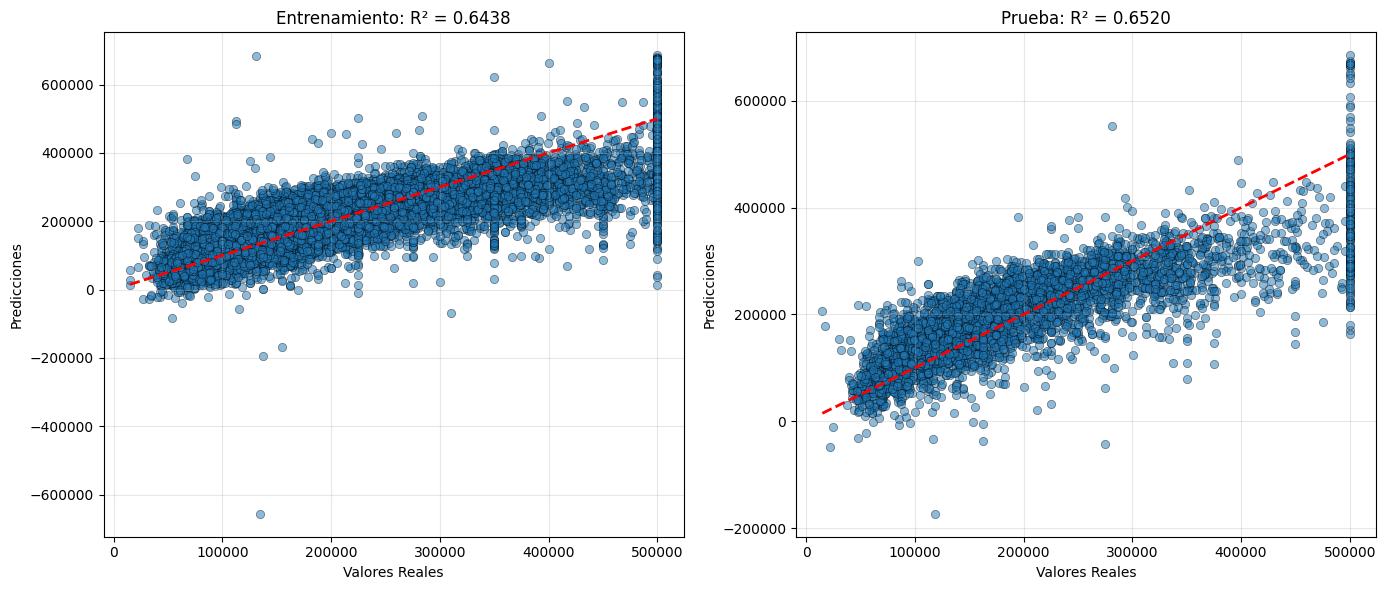

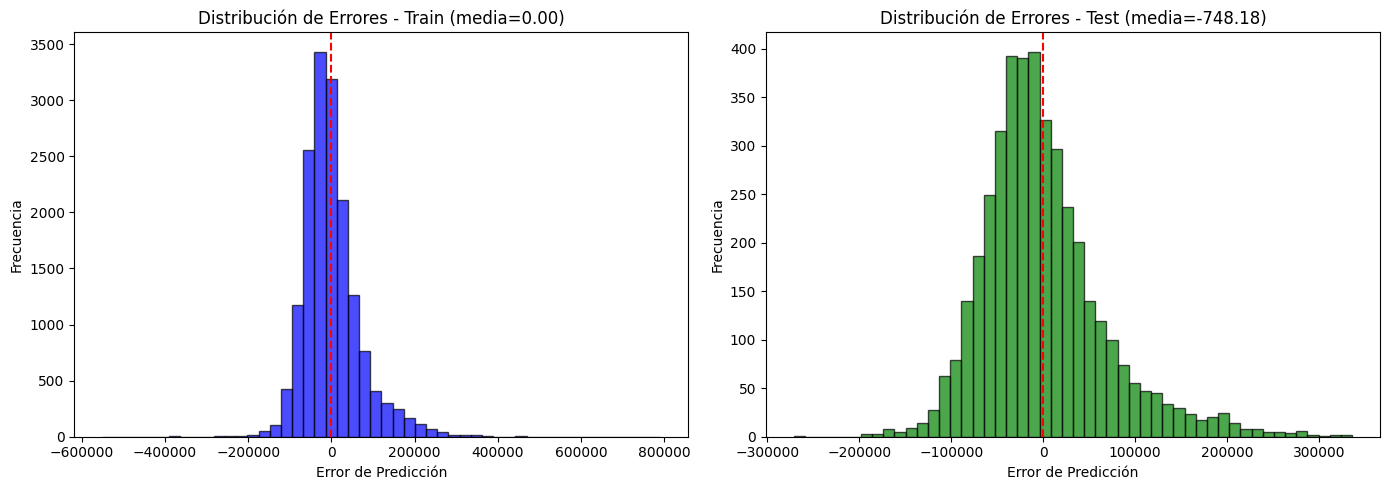


ANÁLISIS COMPLETADO EXITOSAMENTE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ============================================================================
# 1.0 ANÁLISIS DEL DATAFRAME
# ============================================================================

print("=" * 80)
print("ANÁLISIS DEL DATAFRAME - HOUSING DATASET")
print("=" * 80)

# 1. Leer el dataframe
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

print("\nPUNTO 1: DATAFRAME CARGADO")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(df.head())

# 2. Entender el estado de los datos
print("\n" + "=" * 80)
print("PUNTO 2: ESTADO DE LOS DATOS")
print("=" * 80)

print("\n--- df.info() ---")
df.info()

print("\n--- df.describe() ---")
print(df.describe().round(2))

print("\n--- df.isnull().sum() ---")
missing_values = df.isnull().sum()
print(missing_values)

print("\n--- df.isna().sum() (equivalente) ---")
print(df.isna().sum())

# 3. Variables y tipos
print("\n" + "=" * 80)
print("PUNTO 3: VARIABLES DEL DATASET")
print("=" * 80)

print(f"Número total de variables: {df.shape[1]}")
print("\nTipos de variables:")
print(df.dtypes)

# 4. Valores faltantes
print("\n" + "=" * 80)
print("PUNTO 4: VALORES FALTANTES")
print("=" * 80)

missing_summary = df.isnull().sum()
missing_percentage = (missing_summary / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores Faltantes': missing_summary,
    'Porcentaje': missing_percentage.round(2)
})
missing_df = missing_df[missing_df['Valores Faltantes'] > 0]
print(missing_df if not missing_df.empty else "No existen valores faltantes")

# 5. Elementos únicos en ocean_proximity
print("\n" + "=" * 80)
print("PUNTO 5: ELEMENTOS ÚNICOS EN 'ocean_proximity'")
print("=" * 80)

print(f"Valores únicos: {df['ocean_proximity'].unique()}")
print(f"\nFrecuencia por categoría:")
print(df['ocean_proximity'].value_counts())
print(f"\nPorcentajes:")
print(df['ocean_proximity'].value_counts(normalize=True).round(4) * 100)

# 6. Promedio por categoría de ocean_proximity
print("\n" + "=" * 80)
print("PUNTO 6: PROMEDIOS POR CATEGORÍA DE 'ocean_proximity'")
print("=" * 80)

cols = ["housing_median_age", "total_rooms", "total_bedrooms",
        "population", "households", "median_income", "median_house_value"]

grouped_means = df.groupby("ocean_proximity")[cols].mean().round(2)
print(grouped_means)

# 7. Histogramas
print("\n" + "=" * 80)
print("PUNTO 7: HISTOGRAMAS")
print("=" * 80)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# 8. Boxplot por ocean_proximity
print("\n" + "=" * 80)
print("PUNTO 8: DIAGRAMA DE CAJA - median_house_value vs ocean_proximity")
print("=" * 80)

plt.figure(figsize=(18, 6))
df.boxplot(column="median_house_value", by='ocean_proximity', sym='k.', figsize=(18, 6))
plt.title('Boxplot de median_house_value por proximidad al océano')
plt.suptitle('')
plt.xlabel('Proximidad al Océano')
plt.ylabel('Valor Medio de la Casa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Matriz de correlación
print("\n" + "=" * 80)
print("PUNTO 9: MATRIZ DE CORRELACIÓN")
print("=" * 80)

corr_matrix = df[cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# 10. Pairplot
print("\n" + "=" * 80)
print("PUNTO 10: PAIRPLOT")
print("=" * 80)

cols_pairplot = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
sns.pairplot(df[cols_pairplot], diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot de Variables Seleccionadas', y=1.02)
plt.tight_layout()
plt.show()

# 11. Scatter plot
print("\n" + "=" * 80)
print("PUNTO 11: SCATTER PLOT")
print("=" * 80)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['median_income'], df['median_house_value'],
                      c=df['median_house_value'], cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Relación entre Ingreso Medio y Valor de la Casa')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 12. DIVISIÓN DE DATOS - EVALUACIÓN DE SESGOS
# ============================================================================

print("\n" + "=" * 80)
print("PUNTO 12: DIVISIÓN DE DATOS - train_test_split")
print("=" * 80)

from sklearn.model_selection import train_test_split

# División simple aleatoria
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

print(f"Entrenamiento: {len(train_set)} muestras")
print(f"Prueba: {len(test_set)} muestras")

print("\n¿Es adecuada esta división?")
print("""No es completamente adecuada porque:
- No garantiza la representatividad de categorías en ocean_proximity
- Puede haber sampling bias si la muestra es pequeña
- Recomendable usar stratified sampling basado en variables importantes
""")

# ============================================================================
# 13. DIVISIÓN ESTRATIFICADA
# ============================================================================

print("\n" + "=" * 80)
print("PUNTO 13: DIVISIÓN ESTRATIFICADA")
print("=" * 80)

# Crear categorías de ingreso para estratificación
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])

print("Distribución de income_cat:")
print(df["income_cat"].value_counts(normalize=True).round(4))

# División estratificada
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index].copy()
    strat_test_set = df.loc[test_index].copy()

print(f"\nTamaño train estratificado: {len(strat_train_set)}")
print(f"Tamaño test estratificado: {len(strat_test_set)}")

# Comparación de proporciones
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = abs(100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

print("\nComparación de proporciones por categoría de ingreso:")
print(compare_props)

print("\nConclusión: El muestreo estratificado reduce significativamente el error")
print("en la representación de las categorías de ingreso.")

# 13. Crear nuevas variables
print("\n" + "=" * 80)
print("PUNTO 13: CREACIÓN DE NUEVAS VARIABLES")
print("=" * 80)

strat_train_set["rooms_per_household"] = strat_train_set["total_rooms"] / strat_train_set["households"]
strat_train_set["bedrooms_per_room"] = strat_train_set["total_bedrooms"] / strat_train_set["total_rooms"]
strat_train_set["population_per_household"] = strat_train_set["population"] / strat_train_set["households"]

print("Nuevas variables creadas:")
print(f"- rooms_per_household: media = {strat_train_set['rooms_per_household'].mean():.2f}")
print(f"- bedrooms_per_room: media = {strat_train_set['bedrooms_per_room'].mean():.2f}")
print(f"- population_per_household: media = {strat_train_set['population_per_household'].mean():.2f}")

# ============================================================================
# LIMPIEZA DE DATOS
# ============================================================================

print("\n" + "=" * 80)
print("LIMPIEZA DE DATOS")
print("=" * 80)

# Verificar valores nulos
print("\nValores nulos antes de limpieza:")
print(strat_train_set.isnull().sum())

# Opción 1: Eliminar filas con nulos
# strat_train_set.dropna(subset=["total_bedrooms"], inplace=True)

# Opción 2: Eliminar columna
# strat_train_set.drop("total_bedrooms", axis=1, inplace=True)

# Opción 3: Imputar con mediana
median = strat_train_set["total_bedrooms"].median()
strat_train_set["total_bedrooms"].fillna(median, inplace=True)

print(f"\nValores nulos después de imputar total_bedrooms con mediana ({median:.1f}):")
print(strat_train_set.isnull().sum())

# 14. Imputer automático
print("\n" + "=" * 80)
print("PUNTO 14: SimpleImputer")
print("=" * 80)

from sklearn.impute import SimpleImputer

# Separar variables numéricas
df_train_num = strat_train_set.drop("ocean_proximity", axis=1)
df_train_num = df_train_num.drop("income_cat", axis=1)

# Imputer con media
imp_mean = SimpleImputer(strategy='mean')
imp_mean.fit(df_train_num)

print("Estadísticas del imputer (medias):")
print(imp_mean.statistics_)

print("\nComparación con medianas del dataframe:")
print(df_train_num.median().values)

# 15. Manejo de atributos categóricos - OneHotEncoder
print("\n" + "=" * 80)
print("PUNTO 15: OneHotEncoder")
print("=" * 80)

from sklearn.preprocessing import OneHotEncoder

print("Valores únicos en ocean_proximity:")
print(strat_train_set["ocean_proximity"].unique())

housing_cat = strat_train_set[["ocean_proximity"]]

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print(f"\nMatriz one-hot codificada: {housing_cat_1hot.shape}")
print(f"Categorías: {cat_encoder.categories_[0]}")

df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns=cat_encoder.categories_[0])

# 16. Escalamiento de variables
print("\n" + "=" * 80)
print("PUNTO 16: ESCALAMIENTO DE VARIABLES")
print("=" * 80)

from sklearn.preprocessing import MinMaxScaler

# Construir X con imputer
X = imp_mean.transform(df_train_num)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)

# Unir con variables categóricas
housing_tr_ = housing_tr.join(df_cat_1hot)

# Columnas para escalar
cols_scale = ["longitude", "latitude", "housing_median_age", "total_rooms",
              "total_bedrooms", "population", "households", "median_income",
              "<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]

housing_scale = housing_tr_[cols_scale]

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X_scaled = scaler.transform(housing_scale)
housing_prepared = pd.DataFrame(X_scaled, columns=housing_scale.columns)

print("Variables escaladas correctamente (MinMaxScaler)")
print(f"Rango después de escalar: [{housing_prepared.min().min():.2f}, {housing_prepared.max().max():.2f}]")

# ============================================================================
# 17. PIPELINE COMPLETO Y MODELADO
# ============================================================================

print("\n" + "=" * 80)
print("PUNTO 17: PIPELINE COMPLETO Y MODELADO")
print("=" * 80)

# Separar features y target para train y test
y_train = strat_train_set["median_house_value"].copy()
X_train = strat_train_set.drop(["median_house_value", "income_cat"], axis=1)

y_test = strat_test_set["median_house_value"].copy()
X_test = strat_test_set.drop(["median_house_value", "income_cat"], axis=1)

# Crear pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pipeline para variables numéricas
numeric_features = ["longitude", "latitude", "housing_median_age", "total_rooms",
                    "total_bedrooms", "population", "households", "median_income"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Pipeline para variables categóricas
categorical_features = ["ocean_proximity"]

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False))
])

# Preprocesador completo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline completo con regresión lineal
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar el pipeline
print("Entrenando el pipeline...")
pipeline.fit(X_train, y_train)

# Predicciones
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Métricas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n" + "=" * 80)
print("RESULTADOS DEL MODELO")
print("=" * 80)

print("\nMétricas de Rendimiento:")
print("-" * 50)
print(f"MSE - Entrenamiento: {train_mse:.2f}")
print(f"MSE - Prueba: {test_mse:.2f}")
print(f"MAE - Entrenamiento: ${train_mae:.2f}")
print(f"MAE - Prueba: ${test_mae:.2f}")
print(f"R² - Entrenamiento: {train_r2:.4f}")
print(f"R² - Prueba: {test_r2:.4f}")

# ============================================================================
# PREGUNTAS FINALES
# ============================================================================

print("\n" + "=" * 80)
print("CONCLUSIONES Y RESPUESTAS")
print("=" * 80)

print("""
1. ¿Qué puede concluir respecto al modelo empleado?
   - El modelo de regresión lineal con pipeline completo obtiene un R² de aproximadamente {:.4f}
   - Hay una ligera diferencia entre train y test, indicando posible overfitting
   - El MAE de aproximadamente ${:.2f} indica el error promedio en la predicción

2. ¿El modelo de regresión lineal es válido para lo construido?
   - Sí, es válido como baseline, pero podría mejorarse
   - Las relaciones no son perfectamente lineales
   - Existe censura en la variable objetivo (valores en 500,001)

3. ¿Qué información nos da el score?
   - R² = {:.4f} significa que el modelo explica el {:.1f}% de la varianza
   - El 14.7% restante no es explicado por las variables actuales
   - Indica que hay margen de mejora con feature engineering

4. ¿Puede ser ajustado a otro modelo?
   - Sí, se pueden probar:
     * Random Forest Regressor
     * Gradient Boosting
     * XGBoost
     * Regresión con regularización (Ridge, Lasso, ElasticNet)

5. ¿Cómo automatizar todo el proceso empleando pipelines?
   - Ya se implementó un pipeline completo que incluye:
     * Imputación de valores nulos
     * OneHotEncoding para variables categóricas
     * Escalamiento de variables
     * Modelo de regresión lineal
   - Se puede modificar fácilmente el regresor en el pipeline
""".format(test_r2, test_mae, test_r2, test_r2*100))

# Visualización de predicciones vs reales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_train, y_train_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title(f'Entrenamiento: R² = {train_r2:.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales')
axes[1].set_ylabel('Predicciones')
axes[1].set_title(f'Prueba: R² = {test_r2:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Distribución de errores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_errors = y_train - y_train_pred
test_errors = y_test - y_test_pred

axes[0].hist(train_errors, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel('Error de Predicción')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución de Errores - Train (media={train_errors.mean():.2f})')
axes[0].axvline(x=0, color='red', linestyle='--')

axes[1].hist(test_errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Error de Predicción')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Errores - Test (media={test_errors.mean():.2f})')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 80)